In [1]:
from __future__ import annotations

import copy
import dataclasses
import enum
import logging
import pathlib
import time
import typing as tp
from collections import defaultdict

from cirbo.core import Circuit, Gate
from cirbo.core.circuit import gate
from cirbo.core.circuit.gate import Label, ALWAYS_TRUE, ALWAYS_FALSE, NOT, AND, INPUT, NAND, OR
from cirbo.minimization import cleanup
from cirbo.minimization.simplification.remove_constant_gates import RemoveConstantGates
from cirbo.minimization.simplification.remove_redundant_gates import RemoveRedundantGates
from cirbo.sat.miter import build_miter
from cirbo.sat.sat import is_circuit_satisfiable, PySATSolverNames, PySatResult

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [2]:
# =============================================================================
# Configuration
# =============================================================================

class SolverStatus(enum.Enum):
    """Status of SAT solver result."""
    SAT = "SAT"
    UNSAT = "UNSAT"
    UNKNOWN = "UNKNOWN"


@dataclasses.dataclass
class SolverConfig:
    """
    Configuration for the Cube-and-Conquer SAT solver.
    
    Attributes:
        size_threshold: Switch to CDCL solver when circuit size drops below this value.
        max_depth: Maximum recursion depth before switching to CDCL solver.
        lookahead_candidates: Number of top candidates to consider for lookahead.
        input_score_boost: Score boost for input gates in branching heuristic.
        output_proximity_boost: Score boost for gates close to outputs.
        solver_name: PySAT solver to use for the Conquer phase.
        enable_linked_gates: Enable linked gates constraint propagation (Rules 6-8).
        verbose: Enable verbose logging.
    """
    size_threshold: int = 500
    max_depth: int = 16
    lookahead_candidates: int = 20
    input_score_boost: int = 100
    output_proximity_boost: int = 50
    solver_name: PySATSolverNames = PySATSolverNames.CADICAL195
    enable_linked_gates: bool = True
    verbose: bool = True


@dataclasses.dataclass
class SolverResult:
    """
    Result of SAT solving.
    
    Attributes:
        status: SAT/UNSAT/UNKNOWN status.
        model: Variable assignments if SAT, None otherwise.
        constraints: The constraints (cube) that led to this result.
        time_seconds: Time taken to solve.
        nodes_explored: Number of nodes explored in the search tree.
    """
    status: SolverStatus
    model: dict[Label, bool] | None = None
    constraints: dict[Label, bool] = dataclasses.field(default_factory=dict)
    time_seconds: float = 0.0
    nodes_explored: int = 0


@dataclasses.dataclass
class ExperimentConfig:
    """
    Configuration for running experiments.
    
    Attributes:
        circuits_base_path: Base path to circuit files.
        circuit_types: List of multiplier types to test (column, dadda, karatsuba, wallace).
        sizes: List of sizes to test (e.g., ["11x11", "12x12"]).
        solver_config: Configuration for the Cube-and-Conquer solver.
        timeout_seconds: Timeout for each experiment in seconds.
    """
    circuits_base_path: str = "/home/vsevolod/Work/IEEE-Access-2024-Supplementary/data/circuits/mult"
    circuit_types: list[str] = dataclasses.field(
        default_factory=lambda: ["column", "karatsuba", "wallace", "dadda"]
    )
    sizes: list[str] = dataclasses.field(
        default_factory=lambda: ["11x11", "12x12"]
    )
    solver_config: SolverConfig = dataclasses.field(default_factory=SolverConfig)
    timeout_seconds: float = 300.0


print("Configuration classes defined successfully!")


Configuration classes defined successfully!


In [3]:
# =============================================================================
# Stage 1: Constraint Propagation (with Linked Gates)
# =============================================================================

class PropagationError(Exception):
    """Exception raised when constraint propagation finds a contradiction."""
    pass


@dataclasses.dataclass  
class LinkedPair:
    """
    Represents a linked pair constraint: NOT(gate1) OR NOT(gate2).
    This means at least one of them must be False.
    """
    gate1: Label
    gate2: Label
    
    def __hash__(self):
        return hash(frozenset([self.gate1, self.gate2]))
    
    def __eq__(self, other):
        if not isinstance(other, LinkedPair):
            return False
        return {self.gate1, self.gate2} == {other.gate1, other.gate2}


class ConstraintPropagator:
    """
    Implements constraint propagation for circuit simplification.
    
    Implements all 8 rules from the paper:
    
    Basic Rules (1-5):
        1. NOT(0) -> 1, NOT(1) -> 0
        2. AND(..., 0, ...) -> 0
        3. AND(..., 1, ...) -> AND(remaining operands) or buffer
        4. Output of AND = 1 -> all inputs are 1
        5. Output of AND = 0 and one input is 1 -> other input is 0
    
    Linked Gates Rules (6-8):
        6. If w = AND(u, v) and w = 0, mark (u, v) as linked (NOT u OR NOT v)
        7. If one linked gate becomes 1 -> other becomes 0
        8. If one linked gate becomes 0 -> remove link, other is free
    """
    
    def __init__(self, circuit: Circuit, config: SolverConfig):
        self.circuit = copy.copy(circuit)
        self.config = config
        self.assignments: dict[Label, bool] = {}
        self.linked_pairs: set[LinkedPair] = set()
        self.propagation_queue: list[tuple[Label, bool]] = []
        
    def assign(self, label: Label, value: bool) -> None:
        """Assign a value to a gate and add to propagation queue."""
        if label in self.assignments:
            if self.assignments[label] != value:
                raise PropagationError(f"Contradiction: {label} already assigned to {self.assignments[label]}, cannot assign {value}")
            return  # Already assigned same value
        
        self.assignments[label] = value
        self.propagation_queue.append((label, value))
        
    def propagate(self) -> Circuit:
        """
        Run constraint propagation until fixpoint.
        Returns simplified circuit.
        Raises PropagationError if contradiction found.
        """
        while self.propagation_queue:
            label, value = self.propagation_queue.pop(0)
            self._propagate_single(label, value)
            
        # Apply assignments to circuit
        return self._apply_assignments()
    
    def _propagate_single(self, label: Label, value: bool) -> None:
        """Propagate a single assignment."""
        g = self.circuit.get_gate(label)
        
        # Check linked gates (Rules 7-8)
        if self.config.enable_linked_gates:
            self._check_linked_gates(label, value)
        
        # Propagate based on gate type and value
        if g.gate_type == NOT:
            # Rule 1: NOT propagation
            self.assign(g.operands[0], not value)
            
        elif g.gate_type == AND:
            if value:
                # Rule 4: Output of AND = 1 -> all inputs are 1
                for operand in g.operands:
                    self.assign(operand, True)
            else:
                # Rule 6: Mark operands as linked if enabled
                if self.config.enable_linked_gates and len(g.operands) == 2:
                    # Check if one operand is already known
                    op0_val = self.assignments.get(g.operands[0])
                    op1_val = self.assignments.get(g.operands[1])
                    
                    if op0_val is True:
                        # Rule 5: One input is 1, other must be 0
                        self.assign(g.operands[1], False)
                    elif op1_val is True:
                        # Rule 5: One input is 1, other must be 0
                        self.assign(g.operands[0], False)
                    elif op0_val is None and op1_val is None:
                        # Rule 6: Both unknown, add linked pair
                        self.linked_pairs.add(LinkedPair(g.operands[0], g.operands[1]))
                        
        elif g.gate_type == gate.NAND:
            if not value:
                # NAND = 0 means AND = 1, so all inputs must be 1
                for operand in g.operands:
                    self.assign(operand, True)
                    
        elif g.gate_type == gate.OR:
            if not value:
                # OR = 0 means all inputs must be 0
                for operand in g.operands:
                    self.assign(operand, False)
            else:
                # OR = 1 with one 0 input means other must be 1
                if len(g.operands) == 2:
                    op0_val = self.assignments.get(g.operands[0])
                    op1_val = self.assignments.get(g.operands[1])
                    if op0_val is False:
                        self.assign(g.operands[1], True)
                    elif op1_val is False:
                        self.assign(g.operands[0], True)
                        
        elif g.gate_type == gate.NOR:
            if value:
                # NOR = 1 means all inputs must be 0
                for operand in g.operands:
                    self.assign(operand, False)
                    
        elif g.gate_type == gate.XOR:
            if len(g.operands) == 2:
                op0_val = self.assignments.get(g.operands[0])
                op1_val = self.assignments.get(g.operands[1])
                if op0_val is not None:
                    self.assign(g.operands[1], value != op0_val)
                elif op1_val is not None:
                    self.assign(g.operands[0], value != op1_val)
                    
        # Also propagate forward to users
        self._propagate_to_users(label, value)
        
    def _propagate_to_users(self, label: Label, value: bool) -> None:
        """Propagate assignment forward to gates that use this gate."""
        users = self.circuit.get_gate_users(label)
        
        for user_label in users:
            user_gate = self.circuit.get_gate(user_label)
            
            if user_gate.gate_type == NOT:
                # Immediate propagation through NOT
                self.assign(user_label, not value)
                
            elif user_gate.gate_type == AND:
                if not value:
                    # Rule 2: AND with 0 input -> 0
                    self.assign(user_label, False)
                else:
                    # Check if all operands are 1
                    all_true = all(
                        self.assignments.get(op) is True 
                        for op in user_gate.operands
                    )
                    if all_true:
                        self.assign(user_label, True)
                        
            elif user_gate.gate_type == gate.OR:
                if value:
                    # OR with 1 input -> 1
                    self.assign(user_label, True)
                else:
                    # Check if all operands are 0
                    all_false = all(
                        self.assignments.get(op) is False 
                        for op in user_gate.operands
                    )
                    if all_false:
                        self.assign(user_label, False)
                        
    def _check_linked_gates(self, label: Label, value: bool) -> None:
        """Check and propagate linked gates constraints."""
        pairs_to_remove = []
        
        for pair in self.linked_pairs:
            if pair.gate1 == label:
                if value:
                    # Rule 7: One linked gate is 1 -> other is 0
                    self.assign(pair.gate2, False)
                    pairs_to_remove.append(pair)
                else:
                    # Rule 8: One linked gate is 0 -> link removed
                    pairs_to_remove.append(pair)
            elif pair.gate2 == label:
                if value:
                    # Rule 7
                    self.assign(pair.gate1, False)
                    pairs_to_remove.append(pair)
                else:
                    # Rule 8
                    pairs_to_remove.append(pair)
                    
        for pair in pairs_to_remove:
            self.linked_pairs.discard(pair)
            
    def _apply_assignments(self) -> Circuit:
        """Apply all assignments to create simplified circuit."""
        new_circuit = copy.copy(self.circuit)
        
        # Replace assigned gates with constants
        for label, value in self.assignments.items():
            if label in new_circuit.gates:
                g = new_circuit.get_gate(label)
                if g.gate_type != INPUT:
                    new_gate_type = ALWAYS_TRUE if value else ALWAYS_FALSE
                    new_circuit._gates[label] = Gate(label, new_gate_type, ())
                    
        # Simplify constant gates
        new_circuit = RemoveConstantGates().transform(new_circuit)
        
        return new_circuit


def propagate_constraints(
    circuit: Circuit, 
    constraints: dict[Label, bool],
    config: SolverConfig
) -> tuple[Circuit, dict[Label, bool]]:
    """
    Apply constraints and propagate.
    
    Args:
        circuit: The circuit to simplify.
        constraints: Initial constraints (gate -> value).
        config: Solver configuration.
        
    Returns:
        Tuple of (simplified_circuit, all_assignments).
        
    Raises:
        PropagationError: If contradiction is found.
    """
    propagator = ConstraintPropagator(circuit, config)
    
    # Add initial constraints
    for label, value in constraints.items():
        propagator.assign(label, value)
    
    # Also propagate from constant gates already in circuit
    for label, g in circuit.gates.items():
        if g.gate_type == ALWAYS_TRUE:
            propagator.assign(label, True)
        elif g.gate_type == ALWAYS_FALSE:
            propagator.assign(label, False)
            
    simplified = propagator.propagate()
    return simplified, propagator.assignments


print("Constraint Propagation implemented!")

Constraint Propagation implemented!


In [4]:
# =============================================================================
# Stage 2: Lookahead Branching Heuristic
# =============================================================================

def get_branching_candidates(circuit: Circuit, config: SolverConfig) -> list[Label]:
    """
    Get candidate gates for branching, sorted by potential impact.
    
    Prioritizes:
    1. Inputs (most direct control)
    2. Gates with high fan-out (affect many gates)
    3. Gates close to outputs
    """
    candidates = []
    
    # Get fan-out counts for scoring
    fan_out: dict[Label, int] = {}
    for label in circuit.gates:
        users = circuit.get_gate_users(label)
        fan_out[label] = len(users)
    
    # Score each gate
    for label, g in circuit.gates.items():
        # Skip constants
        if g.gate_type in (ALWAYS_TRUE, ALWAYS_FALSE):
            continue
            
        score = fan_out.get(label, 0)
        
        # Boost inputs
        if g.gate_type == INPUT:
            score += config.input_score_boost
            
        # Boost gates used by outputs
        for output in circuit.outputs:
            if output in circuit.gates:
                if label in circuit.get_gate(output).operands:
                    score += config.output_proximity_boost
                
        candidates.append((label, score))
    
    # Sort by score descending and return top candidates
    candidates.sort(key=lambda x: -x[1])
    return [label for label, _ in candidates[:config.lookahead_candidates]]


def compute_lookahead_score(
    circuit: Circuit, 
    label: Label, 
    config: SolverConfig
) -> float:
    """
    Compute lookahead score for a branching candidate.
    
    Score = H_0 * H_1 where:
        H_0 = number of gates simplified/removed when label=0
        H_1 = number of gates simplified/removed when label=1
        
    This is the classic "mix-product" heuristic.
    """
    original_size = circuit.size
    
    def try_assignment(value: bool) -> int:
        """Try assigning value and count simplifications."""
        try:
            simplified, _ = propagate_constraints(
                circuit, 
                {label: value}, 
                config
            )
            return max(0, original_size - simplified.size)
        except PropagationError:
            # Contradiction found - this is very valuable info!
            # Return a high score to indicate this branch can be pruned
            return original_size
    
    h_0 = try_assignment(False)
    h_1 = try_assignment(True)
    
    # Mix-product heuristic
    # Add 1 to avoid zero products
    return (h_0 + 1) * (h_1 + 1)


def find_best_branching_node(circuit: Circuit, config: SolverConfig) -> Label | None:
    """
    Find the best node for branching using lookahead.
    
    Returns None if no suitable branching node found.
    """
    candidates = get_branching_candidates(circuit, config)
    
    if not candidates:
        return None
    
    best_label = None
    best_score = -1
    
    for label in candidates:
        score = compute_lookahead_score(circuit, label, config)
        if score > best_score:
            best_score = score
            best_label = label
            
        if config.verbose:
            logger.debug(f"Lookahead: {label} -> score={score}")
    
    return best_label


print("Lookahead Branching Heuristic implemented!")

Lookahead Branching Heuristic implemented!


In [5]:
# =============================================================================
# Stage 3: Cube-and-Conquer Main Algorithm  
# =============================================================================

class CubeAndConquerSolver:
    """
    Cube-and-Conquer SAT solver for circuits.
    
    The strategy divides a complex problem into simpler subproblems (cubes)
    that are solved by an external CDCL solver (conquer).
    """
    
    def __init__(self, config: SolverConfig):
        self.config = config
        self.nodes_explored = 0
        self.start_time = 0.0
        
    def solve(self, circuit: Circuit) -> SolverResult:
        """
        Solve the circuit SAT problem.
        
        The circuit must have exactly one output, which is forced to True.
        
        Raises:
            ValueError: If circuit does not have exactly one output.
        """
        if len(circuit.outputs) != 1:
            raise ValueError(
                f"Circuit must have exactly one output, got {len(circuit.outputs)}"
            )
        
        self.nodes_explored = 0
        self.start_time = time.time()
        
        # Force output to True (we want to find an assignment making output True)
        initial_constraints = {circuit.outputs[0]: True}
            
        result = self._solve_recursive(circuit, initial_constraints, depth=0)
        result.time_seconds = time.time() - self.start_time
        result.nodes_explored = self.nodes_explored
        
        return result
    
    def _solve_recursive(
        self, 
        circuit: Circuit, 
        constraints: dict[Label, bool],
        depth: int
    ) -> SolverResult:
        """Recursive Cube-and-Conquer solving."""
        self.nodes_explored += 1
        
        # Step 1: Apply constraints and propagate
        try:
            simplified, assignments = propagate_constraints(
                circuit, constraints, self.config
            )
        except PropagationError:
            # Contradiction found - this branch is UNSAT
            return SolverResult(
                status=SolverStatus.UNSAT,
                constraints=constraints
            )
        
        # Step 2: Check for trivial solution
        trivial_result = self._check_trivial(simplified, assignments)
        if trivial_result is not None:
            return trivial_result
        
        # Step 3: Check cutoff condition - switch to base solver
        if self._should_cutoff(simplified, depth):
            return self._solve_with_base_solver(simplified, assignments)
        
        # Step 4: Find best branching node and recurse
        branch_node = find_best_branching_node(simplified, self.config)
        
        if branch_node is None:
            # No branching candidates - use base solver
            return self._solve_with_base_solver(simplified, assignments)
        
        if self.config.verbose:
            logger.info(f"Depth {depth}: Branching on {branch_node}, circuit size={simplified.size}")
        
        # Try branch_node = False first
        result_false = self._solve_recursive(
            simplified,
            {**assignments, branch_node: False},
            depth + 1
        )
        
        if result_false.status == SolverStatus.SAT:
            return result_false
        
        # Try branch_node = True
        result_true = self._solve_recursive(
            simplified,
            {**assignments, branch_node: True},
            depth + 1
        )
        
        if result_true.status == SolverStatus.SAT:
            return result_true
        
        # Both branches UNSAT
        return SolverResult(
            status=SolverStatus.UNSAT,
            constraints=assignments
        )
    
    def _check_trivial(
        self, 
        circuit: Circuit, 
        assignments: dict[Label, bool]
    ) -> SolverResult | None:
        """Check if the circuit has a trivial solution (single output only)."""
        if len(circuit.outputs) != 1:
            raise ValueError("Circuit must have exactly one output")
        
        output = circuit.outputs[0]
        
        # Check if output is determined
        if output in assignments:
            output_value = assignments[output]
        else:
            g = circuit.get_gate(output)
            if g.gate_type == ALWAYS_TRUE:
                output_value = True
            elif g.gate_type == ALWAYS_FALSE:
                output_value = False
            else:
                # Output not determined yet
                return None
        
        if output_value:
            # Output is True -> SAT
            model = {}
            for inp in circuit.inputs:
                if inp in assignments:
                    model[inp] = assignments[inp]
                else:
                    model[inp] = False  # Default unassigned inputs to False
                    
            return SolverResult(
                status=SolverStatus.SAT,
                model=model,
                constraints=assignments
            )
        else:
            # Output is False -> UNSAT under current constraints
            return SolverResult(
                status=SolverStatus.UNSAT,
                constraints=assignments
            )
    
    def _should_cutoff(self, circuit: Circuit, depth: int) -> bool:
        """Check if we should switch to is_circuit_satisfiable."""
        return (
            circuit.size < self.config.size_threshold or
            depth >= self.config.max_depth
        )
    
    def _solve_with_base_solver(
        self, 
        circuit: Circuit, 
        assignments: dict[Label, bool]
    ) -> SolverResult:
        """Solve using is_circuit_satisfiable as the base case."""
        try:
            # Apply known assignments as constants
            modified_circuit = copy.copy(circuit)
            
            for label, value in assignments.items():
                if label in modified_circuit.gates:
                    g = modified_circuit.get_gate(label)
                    if g.gate_type == INPUT:
                        new_type = ALWAYS_TRUE if value else ALWAYS_FALSE
                        modified_circuit._gates[label] = Gate(label, new_type, ())
                        if label in modified_circuit._inputs:
                            modified_circuit._inputs.remove(label)
            
            modified_circuit = RemoveConstantGates().transform(modified_circuit)
            
            result = is_circuit_satisfiable(
                modified_circuit,
                solver_name=self.config.solver_name
            )
            
            if result.answer:
                model = dict(assignments)
                return SolverResult(
                    status=SolverStatus.SAT,
                    model=model,
                    constraints=assignments
                )
            else:
                return SolverResult(
                    status=SolverStatus.UNSAT,
                    constraints=assignments
                )
                
        except Exception as e:
            if self.config.verbose:
                logger.warning(f"Base solver error: {e}")
            return SolverResult(
                status=SolverStatus.UNKNOWN,
                constraints=assignments
            )


def solve_circuit_sat(circuit: Circuit, config: SolverConfig | None = None) -> SolverResult:
    """
    Solve circuit SAT using Cube-and-Conquer.
    
    Args:
        circuit: The circuit to solve (output should be True for SAT).
        config: Solver configuration.
        
    Returns:
        SolverResult with status and model.
    """
    if config is None:
        config = SolverConfig()
    
    solver = CubeAndConquerSolver(config)
    return solver.solve(circuit)


print("Cube-and-Conquer Algorithm implemented!")

Cube-and-Conquer Algorithm implemented!


In [6]:
# =============================================================================
# Stage 4: Experiment Runner
# =============================================================================

@dataclasses.dataclass
class ExperimentResult:
    """Result of a single experiment comparing two multiplier implementations."""
    miter_name: str
    mult_type1: str
    mult_type2: str
    size: str
    miter_gates: int
    
    # is_circuit_satisfiable (baseline) results
    baseline_time: float
    baseline_status: str
    
    # Cube-and-Conquer results
    cnc_time: float
    cnc_status: str
    cnc_nodes: int
    
    # Speedup (baseline_time / cnc_time)
    speedup: float
    
    def __str__(self):
        return (
            f"{self.miter_name}: gates={self.miter_gates}, "
            f"baseline={self.baseline_time:.3f}s ({self.baseline_status}), "
            f"C&C={self.cnc_time:.3f}s ({self.cnc_status}, nodes={self.cnc_nodes}), "
            f"speedup={self.speedup:.2f}x"
        )


class ExperimentRunner:
    """Runs experiments comparing is_circuit_satisfiable vs Cube-and-Conquer."""
    
    def __init__(self, config: ExperimentConfig):
        self.config = config
        self.results: list[ExperimentResult] = []
        
    def run_all(self) -> list[ExperimentResult]:
        """
        Run all experiments.
        
        For each size, creates miter circuits between all pairs of different 
        multiplier types to check equivalence.
        """
        self.results = []
        
        # Generate all pairs of different multiplier types
        type_pairs = [
            (t1, t2) 
            for i, t1 in enumerate(self.config.circuit_types) 
            for t2 in self.config.circuit_types[i+1:]
        ]
        
        for size in self.config.sizes:
            for type1, type2 in type_pairs:
                result = self._run_single(type1, type2, size)
                if result:
                    self.results.append(result)
                    print(result)
                    
        return self.results
    
    def _run_single(
        self, 
        type1: str, 
        type2: str, 
        size: str
    ) -> ExperimentResult | None:
        """Run a single experiment comparing two multiplier types."""
        miter_name = f"{type1}_vs_{type2}_{size}"
        
        path1 = (
            pathlib.Path(self.config.circuits_base_path) / 
            type1 / 
            f"{type1}{size}.aig"
        )
        path2 = (
            pathlib.Path(self.config.circuits_base_path) / 
            type2 / 
            f"{type2}{size}.aig"
        )
        
        if not path1.exists():
            logger.warning(f"Circuit not found: {path1}")
            return None
        if not path2.exists():
            logger.warning(f"Circuit not found: {path2}")
            return None
            
        try:
            logger.info(f"Building miter: {miter_name}")
            
            # Load the two different multiplier implementations
            circuit1 = Circuit.from_aig_file(str(path1), binary=False)
            circuit2 = Circuit.from_aig_file(str(path2), binary=False)
            
            # Build miter circuit
            miter = build_miter(circuit1, circuit2)
            miter_gates = miter.size
            
            logger.info(f"Miter circuit built: {miter_gates} gates")
            
            # Run baseline (is_circuit_satisfiable)
            baseline_start = time.time()
            try:
                baseline_result = is_circuit_satisfiable(
                    miter, 
                    solver_name=self.config.solver_config.solver_name
                )
                baseline_time = time.time() - baseline_start
                baseline_status = "SAT" if baseline_result.answer else "UNSAT"
            except Exception as e:
                baseline_time = time.time() - baseline_start
                baseline_status = f"ERROR: {e}"
            
            # Run Cube-and-Conquer
            cnc_start = time.time()
            try:
                cnc_result = solve_circuit_sat(miter, self.config.solver_config)
                cnc_time = cnc_result.time_seconds
                cnc_status = cnc_result.status.value
                cnc_nodes = cnc_result.nodes_explored
            except Exception as e:
                cnc_time = time.time() - cnc_start
                cnc_status = f"ERROR: {e}"
                cnc_nodes = 0
            
            # Calculate speedup
            if cnc_time > 0:
                speedup = baseline_time / cnc_time
            else:
                speedup = 0.0
                
            return ExperimentResult(
                miter_name=miter_name,
                mult_type1=type1,
                mult_type2=type2,
                size=size,
                miter_gates=miter_gates,
                baseline_time=baseline_time,
                baseline_status=baseline_status,
                cnc_time=cnc_time,
                cnc_status=cnc_status,
                cnc_nodes=cnc_nodes,
                speedup=speedup
            )
            
        except Exception as e:
            logger.error(f"Error running experiment for {miter_name}: {e}")
            return None
    
    def print_summary(self):
        """Print summary of results."""
        if not self.results:
            print("No results to summarize")
            return
            
        print("\n" + "=" * 80)
        print("EXPERIMENT SUMMARY")
        print("=" * 80)
        
        total_baseline = sum(r.baseline_time for r in self.results)
        total_cnc = sum(r.cnc_time for r in self.results)
        
        print(f"\nTotal baseline (is_circuit_satisfiable) time: {total_baseline:.3f}s")
        print(f"Total Cube-and-Conquer time: {total_cnc:.3f}s")
        
        if total_cnc > 0:
            print(f"Overall speedup: {total_baseline / total_cnc:.2f}x")
        
        print("\nBy size:")
        for size in set(r.size for r in self.results):
            size_results = [r for r in self.results if r.size == size]
            avg_speedup = sum(r.speedup for r in size_results) / len(size_results)
            print(f"  {size}: avg speedup = {avg_speedup:.2f}x")
            

def run_experiments(config: ExperimentConfig | None = None) -> list[ExperimentResult]:
    """Run all experiments with given config."""
    if config is None:
        config = ExperimentConfig()
    
    runner = ExperimentRunner(config)
    results = runner.run_all()
    runner.print_summary()
    
    return results


print("Experiment Runner implemented!")

Experiment Runner implemented!


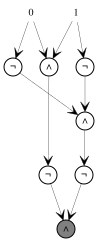

In [7]:
from cirbo.core.circuit.circuit import Circuit
from cirbo.core.circuit.gate import Gate, AND, NOT  # Added NOT to imports

# Initialize a circuit with 2 inputs (A and B)
xor_ckt = Circuit.bare_circuit(input_size=2)

in_a = xor_ckt.inputs[0]
in_b = xor_ckt.inputs[1]

# Logic: XOR(A, B) = NOT( AND(NOT A, NOT B) ) AND NOT( AND(A, B) )
# 1. Invert the inputs
xor_ckt.add_gate(Gate('not_a', NOT, (in_a,)))
xor_ckt.add_gate(Gate('not_b', NOT, (in_b,)))

# 2. Node 1: Check if both are False (0,0) -> (NOT A) AND (NOT B)
xor_ckt.add_gate(Gate('both_false', AND, ('not_a', 'not_b')))
xor_ckt.add_gate(Gate('both_true', AND, (in_a, in_b)))

# 4. Invert the intermediate results (Edges in a standard AIG)
xor_ckt.add_gate(Gate('not_both_false', NOT, ('both_false',)))
xor_ckt.add_gate(Gate('not_both_true', NOT, ('both_true',)))

# 5. Node 3: Combine them -> (NOT Node1) AND (NOT Node2)
xor_ckt.add_gate(Gate('xor_out', AND, ('not_both_false', 'not_both_true')))

xor_ckt.mark_as_output('xor_out')
xor_ckt.into_graphviz_digraph()

In [8]:
def build_aig_miter(
    left: Circuit,
    right: Circuit,
) -> Circuit:
    from cirbo.synthesis.generation import generate_pairwise_xor
    from cirbo.core.circuit import Circuit, gate
    from cirbo.sat.exceptions import MiterDifferentShapesError


    if (left.output_size != 1) or (right.output_size != 1):
        assert False
    left_name = "ckt1"
    right_name = "ckt2"
    miter = Circuit().add_circuit(left, name=left_name)
    miter.connect_circuit(
        right,
        miter.get_block(left_name).inputs,
        right.inputs,
        name=right_name,
    )
    miter.connect_circuit(
        xor_ckt,
        miter.get_block(left_name).outputs + miter.get_block(right_name).outputs,
        xor_ckt.inputs,
        name="xor"
    )
    miter.set_outputs(miter.get_block("xor").outputs)

    return miter

In [9]:
def run_verification_experiment():
    """Run a simple verification experiment with small circuits."""
    
    # circuit1_path = "/home/vsevolod/Work/cirbo/xaig_sum16_size59.bench"
    # circuit2_path = "/home/vsevolod/Work/cirbo/aig_sum16_size89.bench"
    # circuit1_path = "/home/vsevolod/Work/cirbo/ex12.aig"
    # circuit2_path = "/home/vsevolod/Work/cirbo/ex12_from_ex74_google.bench"

    circuit1_path = "/home/vsevolod/Work/cirbo/transalg_mul1.aig"
    circuit2_path = "/home/vsevolod/Work/cirbo/transalg_mul1.aig"

    print("=" * 80)
    print("VERIFICATION EXPERIMENT")
    print("=" * 80)
    print(f"\nCircuit 1: {circuit1_path}")
    print(f"Circuit 2: {circuit2_path}")
    
    # Load circuits
    circuit1 = Circuit.from_aig_file(circuit1_path, binary=False)
    circuit2 = Circuit.from_aig_file(circuit2_path, binary=False)
    
    print(f"\nCircuit 1: {circuit1.size} gates, {circuit1.input_size} inputs, {circuit1.output_size} outputs")
    print(f"Circuit 2: {circuit2.size} gates, {circuit2.input_size} inputs, {circuit2.output_size} outputs")
    
    # Build miter
    miter = build_aig_miter(circuit1, circuit2)
    print(f"\nMiter circuit: {miter.size} gates")
    
    # Configure solver
    config = SolverConfig(
        size_threshold=50,  # Small threshold for this test
        max_depth=20,
        lookahead_candidates=5,
        enable_linked_gates=True,
        verbose=True
    )
    miter.into_graphviz_digraph(draw_blocks=True, draw_labels=True).render(view=True)
    # Run baseline: is_circuit_satisfiable
    print("\n--- Running baseline (is_circuit_satisfiable) ---")
    baseline_start = time.time()
    baseline_result = is_circuit_satisfiable(miter)
    baseline_time = time.time() - baseline_start
    print(f"Baseline result: {'SAT' if baseline_result.answer else 'UNSAT'}")
    print(f"Baseline time: {baseline_time:.4f}s")
    
    # Run Cube-and-Conquer
    print("\n--- Running Cube-and-Conquer ---")
    cnc_start = time.time()
    cnc_result = solve_circuit_sat(miter, config)
    cnc_time = cnc_result.time_seconds
    print(f"C&C result: {cnc_result.status.value}")
    print(f"C&C time: {cnc_time:.4f}s")
    print(f"C&C nodes explored: {cnc_result.nodes_explored}")
    
    # Summary
    print("\n" + "=" * 80)
    print("SUMMARY")
    print("=" * 80)
    print(f"Baseline time: {baseline_time:.4f}s")
    print(f"C&C time: {cnc_time:.4f}s")
    if cnc_time > 0:
        print(f"Speedup: {baseline_time / cnc_time:.2f}x")
    
    # Verify results match
    baseline_sat = baseline_result.answer
    cnc_sat = cnc_result.status == SolverStatus.SAT
    if baseline_sat == cnc_sat:
        print(f"\n✓ Results MATCH: both say {'SAT' if baseline_sat else 'UNSAT'}")
    else:
        print(f"\n✗ Results MISMATCH: baseline={'SAT' if baseline_sat else 'UNSAT'}, C&C={cnc_result.status.value}")
    
    return baseline_result, cnc_result

# Run the verification
baseline_result, cnc_result = run_verification_experiment()

VERIFICATION EXPERIMENT

Circuit 1: /home/vsevolod/Work/cirbo/transalg_mul1.aig
Circuit 2: /home/vsevolod/Work/cirbo/transalg_mul1.aig

Circuit 1: 5 gates, 2 inputs, 1 outputs
Circuit 2: 5 gates, 2 inputs, 1 outputs

Miter circuit: 15 gates

--- Running baseline (is_circuit_satisfiable) ---
Baseline result: UNSAT
Baseline time: 0.0042s

--- Running Cube-and-Conquer ---
C&C result: SAT
C&C time: 0.0006s
C&C nodes explored: 1

SUMMARY
Baseline time: 0.0042s
C&C time: 0.0006s
Speedup: 6.88x

✗ Results MISMATCH: baseline=UNSAT, C&C=SAT


In [8]:
# =============================================================================
# Run Experiments
# =============================================================================

# Configure the experiment
experiment_config = ExperimentConfig(
    circuits_base_path="/home/vsevolod/Work/IEEE-Access-2024-Supplementary/data/circuits/mult",
    circuit_types=[
        "column",
        # "karatsuba",
        "wallace"
    ],  # Different multiplier implementations
    sizes=[
        "11x11", 
        # "12x12"
        ],  # Sizes to compare
    solver_config=SolverConfig(
        size_threshold=2500,
        max_depth=30,
        lookahead_candidates=20,
        enable_linked_gates=True,
        verbose=True
    ),
    timeout_seconds=60.0
)

# Show what miter circuits will be built
type_pairs = [
    (t1, t2) 
    for i, t1 in enumerate(experiment_config.circuit_types) 
    for t2 in experiment_config.circuit_types[i+1:]
]

print("Experiment configuration:")
print(f"  Circuits path: {experiment_config.circuits_base_path}")
print(f"  Multiplier types: {experiment_config.circuit_types}")
print(f"  Sizes: {experiment_config.sizes}")
print(f"  Miter pairs to compare: {type_pairs}")
print(f"  Total experiments: {len(type_pairs) * len(experiment_config.sizes)}")


Experiment configuration:
  Circuits path: /home/vsevolod/Work/IEEE-Access-2024-Supplementary/data/circuits/mult
  Multiplier types: ['column', 'wallace']
  Sizes: ['11x11']
  Miter pairs to compare: [('column', 'wallace')]
  Total experiments: 1


In [ ]:
# Run the experiments
print("Starting experiments...")
print("=" * 80)

results = run_experiments(experiment_config)


2025-12-04 01:04:16,701 - INFO - Building miter: column_vs_wallace_11x11
2025-12-04 01:04:16,746 - INFO - Miter circuit built: 5223 gates
